In [1]:
from smalldiffusion.wavedata import npyDataResized, npyDataWndHist
from torch.utils.data import DataLoader
from smalldiffusion.model import Scaled
from smalldiffusion.model_unet import myUnet
from torch_ema import ExponentialMovingAverage as EMA
import torch
import numpy as np
import os
from matplotlib import pyplot as plt
from smalldiffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, ScheduleLDM
from accelerate import Accelerator

%load_ext autoreload
%autoreload 2

### Choose case and checkpoint

#### Without history

In [3]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('wave_200804', 'forcing_200804')]
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']

### Construct test dataset
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataResized(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True,
    compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf
)

In [ ]:
RESUME = True
epoch = 16
path = '../run/global/log1p/DDPM3/'
weights_file = path + f'ckpt_{epoch}.pt'

# model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=128, precond_ch=3, 
#                        scale=(test.meanx, test.stdx, test.meanf, test.stdf),
#                        ch_mult=(1, 2, 2, 2), attn_resolutions=(16,))  

model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=192, precond_ch=3, 
                       scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,)) 

#### With history

In [2]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('wave_200804', 'forcing_200804')]
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']

test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('wave_200804', 'forcing_200804')]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataWndHist(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf
)

In [10]:
RESUME = True
epoch = 17
path = '/global/homes/j/jiarongw/scratch_folder/log1p/DDPM4/'
weights_file = path + f'ckpt_{epoch}.pt'

model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=256, precond_ch=5, 
                       scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))  

### Compute noise level loss

In [11]:
ema = EMA(model.parameters(), decay=0.999)
    
if RESUME:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])

loader_test = DataLoader(test, batch_size=10, shuffle=True)
a = Accelerator()
model, loader_test = a.prepare(model, loader_test)
ema.to(a.device)

loader_test_iter = iter(loader_test)
x, f, mask = next(loader_test_iter)

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)

import torch.nn as nn
losses = torch.zeros([4, len(schedule.sigmas)])
with torch.no_grad():
    for i, s in enumerate(schedule.sigmas):
        print(f'Loss level {i}...')
        sigma = s.expand(x.shape[0]).to(x)
        while len(sigma.shape) < len(x.shape):
            sigma = sigma.unsqueeze(-1)
        eps = torch.randn_like(x)
        eps = eps * mask
        pred_eps = model.forward(x + sigma * eps, sigma, cond=f) * mask
        print(nn.MSELoss()(eps, pred_eps))
        for j in range(0, 4): # Field wise loss
            losses[j, i] = nn.MSELoss()(eps[:,j], pred_eps[:,j])
        print(torch.mean(losses[:,i]))
     
torch.save(losses, path + f'noise_level_loss_by_field_epoch{epoch}.pt')

Loss level 0...
tensor(0.2917, device='cuda:0')
tensor(0.2917)
Loss level 1...
tensor(0.2268, device='cuda:0')
tensor(0.2268)
Loss level 2...
tensor(0.1694, device='cuda:0')
tensor(0.1694)
Loss level 3...
tensor(0.1230, device='cuda:0')
tensor(0.1230)
Loss level 4...
tensor(0.0867, device='cuda:0')
tensor(0.0867)
Loss level 5...
tensor(0.0588, device='cuda:0')
tensor(0.0588)
Loss level 6...
tensor(0.0387, device='cuda:0')
tensor(0.0387)
Loss level 7...
tensor(0.0248, device='cuda:0')
tensor(0.0248)
Loss level 8...
tensor(0.0157, device='cuda:0')
tensor(0.0157)
Loss level 9...
tensor(0.0098, device='cuda:0')
tensor(0.0098)
Loss level 10...
tensor(0.0060, device='cuda:0')
tensor(0.0060)
Loss level 11...
tensor(0.0037, device='cuda:0')
tensor(0.0037)
Loss level 12...
tensor(0.0023, device='cuda:0')
tensor(0.0023)
Loss level 13...
tensor(0.0014, device='cuda:0')
tensor(0.0014)
Loss level 14...
tensor(0.0009, device='cuda:0')
tensor(0.0009)
Loss level 15...
tensor(0.0006, device='cuda:0')
t

In [6]:
schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)
losses = []
with torch.no_grad():
    for s in schedule.sigmas:
        sigma = s.expand(x.shape[0])
        while len(sigma.shape) < len(x.shape):
            sigma = sigma.unsqueeze(-1)
        eps = torch.randn_like(x)
        eps = eps * mask
        loss = model.get_loss_masked(x, sigma, eps, mask=mask, cond=f)
        print(loss.item())
        losses.append(loss.item())
        
torch.save(losses, path + f'noise_level_loss_epoch{epoch}.pt')

0.3358749747276306
0.264634370803833
0.20008616149425507
0.14582017064094543
0.10334733873605728
0.07090029865503311
0.04717688634991646
0.03067578375339508
0.019773295149207115
0.012663367204368114
0.008058266714215279
0.005095547065138817
0.0032534017227590084
0.0020888771396130323
0.0013624404091387987
0.000964268809184432
0.0006953436532057822
0.0005561521393246949
0.0004919187631458044
0.00045680953189730644


In [4]:
# Read from file
path = '/global/homes/j/jiarongw/scratch_folder/'
loss5_ = torch.load(path + 'log1p/loglinear5/noise_level_loss_epoch4.pt')
loss6_ = torch.load(path + 'log1p/loglinear5/noise_level_loss_epoch8.pt')
loss7_ = torch.load(path + 'log1p/DDPM3/noise_level_loss_by_field_epoch8.pt')
loss8_ = torch.load(path + 'log1p/DDPM3/noise_level_loss_by_field_epoch12.pt')
loss9_ = torch.load(path + 'log1p/DDPM3/noise_level_loss_by_field_epoch16.pt')
# loss10_ = torch.load(path + 'log1p/DDPM4/noise_level_loss_by_field_epoch8.pt')
# loss11_ = torch.load(path + 'log1p/DDPM4/noise_level_loss_by_field_epoch12.pt')
# loss12_ = torch.load(path + 'log1p/DDPM4/noise_level_loss_by_field_epoch16.pt')
# loss13_ = torch.load(path + 'log1p/DDPM4/noise_level_loss_by_field_epoch17.pt')

### Loss averaged across four fields

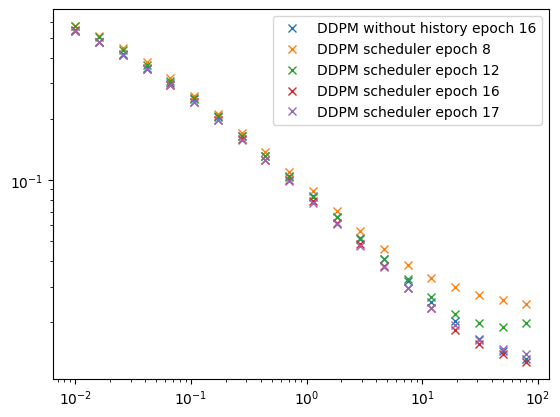

In [25]:
# plt.plot(schedule.sigmas, torch.tensor(loss1)**0.5, '+', label='Loglinear scheduler epoch 4')
# plt.plot(schedule.sigmas, torch.tensor(loss2)**0.5, '+', label='Loglinear scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss3)**0.5, 'x', label='DDPM scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss4)**0.5, 'x', label='DDPM scheduler epoch 12')
# plt.plot(schedule.sigmas, torch.mean(loss5_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')
# plt.plot(schedule.sigmas, torch.mean(loss6_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 24')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)
plt.plot(schedule.sigmas, torch.mean(loss9_, dim=0)**0.5, 'x', label='DDPM without history epoch 16')
plt.plot(schedule.sigmas, torch.mean(loss10_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss11_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 12')
plt.plot(schedule.sigmas, torch.mean(loss12_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')
plt.plot(schedule.sigmas, torch.mean(loss13_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 17')


plt.yscale('log')
plt.xscale('log')
plt.legend()

Text(0, 0.5, 'RMSE loss')

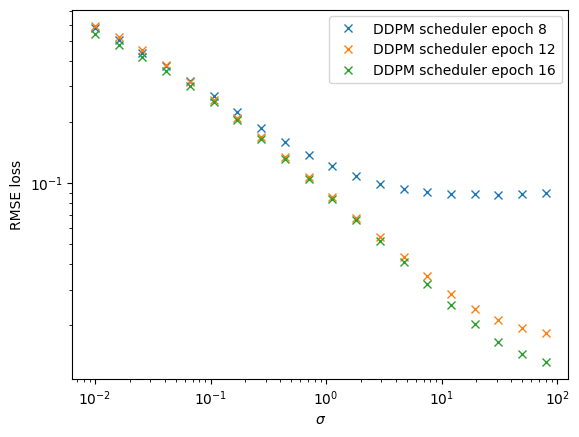

In [11]:
# plt.plot(schedule.sigmas, torch.tensor(loss1)**0.5, '+', label='Loglinear scheduler epoch 4')
# plt.plot(schedule.sigmas, torch.tensor(loss2)**0.5, '+', label='Loglinear scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss3)**0.5, 'x', label='DDPM scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss4)**0.5, 'x', label='DDPM scheduler epoch 12')
# plt.plot(schedule.sigmas, torch.mean(loss5_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')
# plt.plot(schedule.sigmas, torch.mean(loss6_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 24')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)
# plt.plot(schedule.sigmas, torch.tensor(loss6_)**0.5, '+', label='Loglinear scheduler epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss7_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss8_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 12')
plt.plot(schedule.sigmas, torch.mean(loss9_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')


plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.xlabel(r'$\sigma$')
plt.ylabel(r'RMSE loss')

Text(0, 0.5, 'RMSE loss')

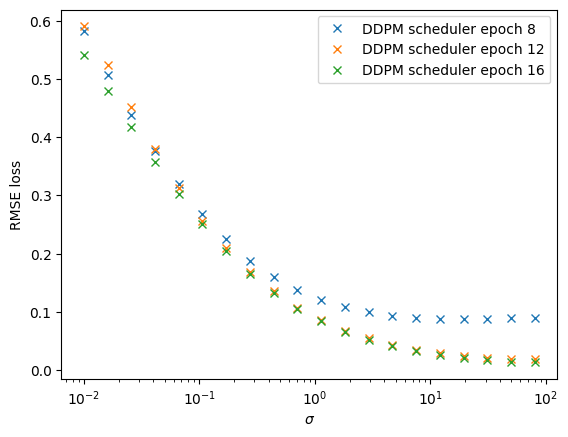

In [12]:
# plt.plot(schedule.sigmas, torch.tensor(loss1)**0.5, '+', label='Loglinear scheduler epoch 4')
# plt.plot(schedule.sigmas, torch.tensor(loss2)**0.5, '+', label='Loglinear scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss3)**0.5, 'x', label='DDPM scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss4)**0.5, 'x', label='DDPM scheduler epoch 12')
# plt.plot(schedule.sigmas, torch.mean(loss5_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')
# plt.plot(schedule.sigmas, torch.mean(loss6_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 24')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)
# plt.plot(schedule.sigmas, torch.tensor(loss6_)**0.5, '+', label='Loglinear scheduler epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss7_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss8_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 12')
plt.plot(schedule.sigmas, torch.mean(loss9_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')


# plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.xlabel(r'$\sigma$')
plt.ylabel(r'RMSE loss')

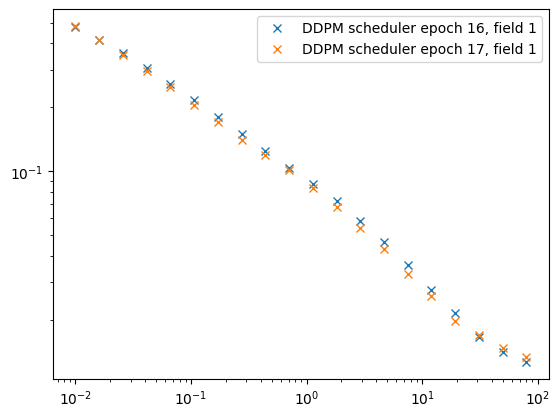

In [28]:
plt.plot(schedule.sigmas, (loss9_[2])**0.5, 'x', label='DDPM scheduler epoch 16, field 1')
plt.plot(schedule.sigmas, (loss12_[2])**0.5, 'x', label='DDPM scheduler epoch 17, field 1')
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [33]:
sigma = schedule.sample_batch(x)
print(sigma.shape)

torch.Size([20])


In [ ]:
loader_test = DataLoader(test, batch_size=10, shuffle=True)
for x, f, mask in loader_test:
    x_masked = x * mask
    eps = torch.randn_like(x)
    size1 = torch.max(abs(x_masked[:,1,:,:]))
    size2 = torch.max(abs(eps[:,1,:,:]))
    print(size1, size2)

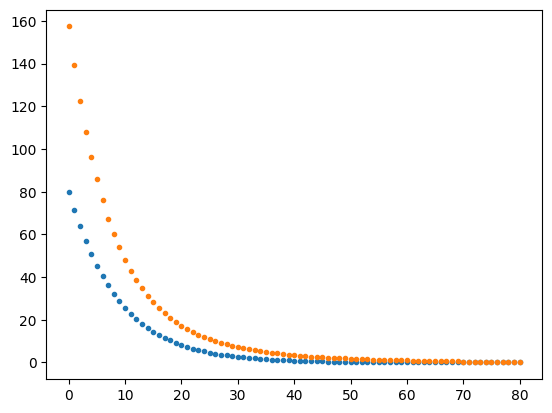

In [6]:
from smalldiffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, ScheduleLDM
schedule1 = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=80)
schedule2 = ScheduleDDPM()
# schedule3 = ScheduleLDM()
sigmas1 = schedule1.sample_sigmas(80)
sigmas2 = schedule2.sample_sigmas(80)
plt.plot(sigmas1, '.')
plt.plot(sigmas2, '.')